step 0: read the documentation (or at least open it): https://l2-python-doc.readthedocs.io/en/latest/state/

step 1: imports. make sure you have the base folder in the same directory and matplotlib and numpy installed. 

In [1]:
import os

# Find the base folder
if not(str(os.getcwd()).split("\\")[-1] == "base folder"):
    os.chdir(str(os.getcwd()) + "\\base folder")
    
from state import Predicate
import inspect
from state_machine import StateMachine
from visualization import run_visualization

step 2: doing the theoretical work of making the model on paper. This includes making the concepts, a graphical representation and semi-formal rules. 

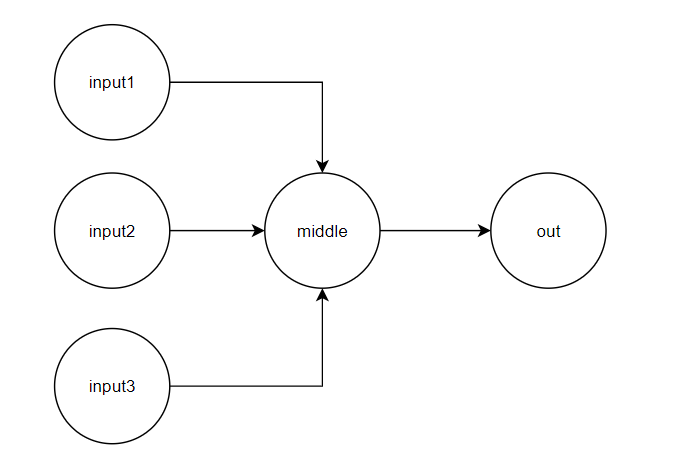

Lets implement this random model with the following semi-formal rules:  
AT EACH TIME STEP if Agent A has input1 X1 AND Agent A has input2 X2 AND Agent A has input3 X3 AND Agent A has middle M  
    THEN NEXT TIME STEP Agent A will have middle M = X3 - X1 - X2 
    
AT EACH TIME STEP if Agent A has middle M = 10  
    THEN NEXT TIME STEP Agent A will have out O = True  
    ELSE NEXT TIME STEP Agent A will have out O = False
    
It's a bit hard to read but basically middle = input3 - input1 - input2 and out = True if middle = 10. 

step 3: create the sorts file. Sorts are the data types that our model can use. Real numbers are built in.  
NOTE: these text files are very fragile!! Do not add comments or empty lines!! Otherwise they explode!!

In [2]:
%%writefile sorts.txt
AGENT;      {arnie, bernie, charlie}

Overwriting sorts.txt


step 4: create the predicates. Predicates is how we represent a concept in a model. It can contain any number of sorts as its values.  
Lets use multiple agents for the inputs just to make it difficult for ourselves.

In [3]:
%%writefile predicates.txt
input1;    {AGENT, AGENT, REAL}
input2;    {AGENT, AGENT, REAL}
input3;    {AGENT, AGENT, REAL}
middle;    {AGENT, REAL}
out;       {AGENT, BOOLEAN}

Overwriting predicates.txt


step 5: create one or more scenarios. Scenarios give the starting values for all predicates. 
- starting nodes (that have no arrow pointing towards them) should have their values defined for the entire simulation
- calculates nodes (the ones with an arrow pointing towards them) should only have their starting value defined

In [4]:
%%writefile scenarios.txt
input1{arnie, bernie, 2}; [1:Inf]
input2{arnie, bernie, 3}; [1:Inf]
input3{arnie, bernie, 15}; [1:Inf]
middle{arnie, 10}; [1]
out{arnie, True}; [1]

Overwriting scenarios.txt


step 6: jeez we only just got to making the actual model?  
now it's time to implement the semi-formal rules. Every calculated node in the graph (the ones with an arrow pointing towards them) should have one and exactly one rule that computes its value (according to your semi-formal rules)
Every rule consists of three parts:
- fetching the required information from the previous time step
- computing the new value for the current time step
- adding the new value to the simulation log


Did you look at the documentation yet?

In [5]:
def calculating_middle(states, t):

    # this is how we get the previous time step containing all previous predicates
    previous_state = states[t - 1]

    # this is how we get the name of the rule we are in 
    rule_name = inspect.stack()[0][3]
    
    # now let's fetch the values we need. We need input 1, 2 and 3
    # we typically use a for loop since there may be multiple agents that have this predicate and they all need to be processed. 
    for input1 in previous_state.get_predicate("input1"):
        
        # problem is we cannot get the next predicate because we need them to be from the same agent
        # so lets get the name of the agent first
        # this is how we get the first agent in the predicate. This should contain arnie
        agent1 = input1.get_name_agent(0)
        
        # this should contain bernie, you could print it if you feel like it (we dont need bernie for this calculation though)
        agent2 = input1.get_name_agent(1)
        #print(agent2)
        
        # now lets get the rest of the values, we need to search by agent
        # this searches a predicate named input2 which contains arnie as first agent
        for input2 in previous_state.get_predicate_by_agent("input2", agent1, 0):
            
            # the for loops are nested because otherwise we would lose our previous variables. 
            for input3 in previous_state.get_predicate_by_agent("input3", agent1, 0):
                
                # now lets get all the values from the predicates. 
                value_input1 = input1.get_value()
                value_input2 = input2.get_value()
                value_input3 = input3.get_value()
                
                # finally we can calculate our new value according to our semi-formal rule that we definitely did not change after realizing it was initially impossible to calculate with code
                new_middle = value_input3 - value_input2 - value_input1
                
                
                # now that we did all that we can finally make a new predicate and return it to our state 
                # think carefully about in which for loop this bit should be
                # wowee i sure hope i did not make any mistakes
                new_predicate = Predicate("middle", [agent1], new_middle)
                states[t].add_predicate_to_state(new_predicate, rule_name)



That was fun! lets make another one to procrascinate on sleeping

In [6]:
def calculating_output(states, t):

    previous_state = states[t - 1]
    rule_name = inspect.stack()[0][3]
    
    # would i still need to put comments in this rule?
    # this is the only predicate we need for calculating output
    for middle in previous_state.get_predicate("middle"):
        
        # we still need the agent 
        agent1 = middle.get_name_agent(0)
        middle_value = middle.get_value()
        
        # this rule is really weird, but thats ok because we are not really modeling anything
        if middle_value == 10:
            new_output = True
        else:
            new_output = False

        new_predicate = Predicate("out", [agent1], new_output)
        states[t].add_predicate_to_state(new_predicate, rule_name)


step 7: you can also add any other python functions you might need. 

step 8: put all your rules (not other functions) in the rules list

In [7]:
rules = [calculating_output, calculating_middle]

step 9: run your model

The following predicates will be visualized:
input1
input2
input3
middle
out


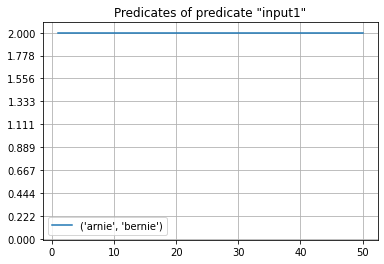

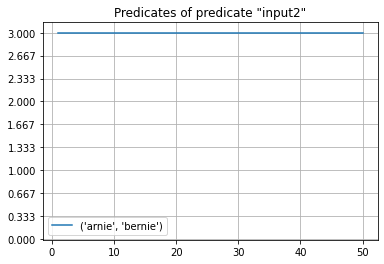

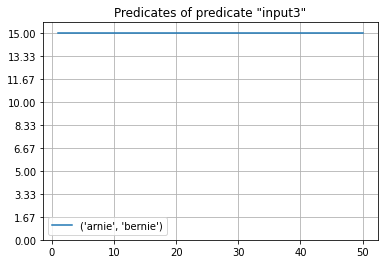

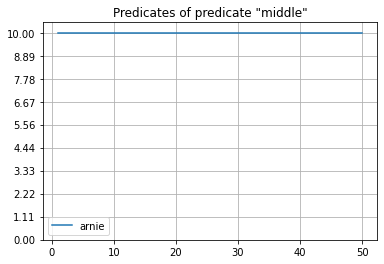

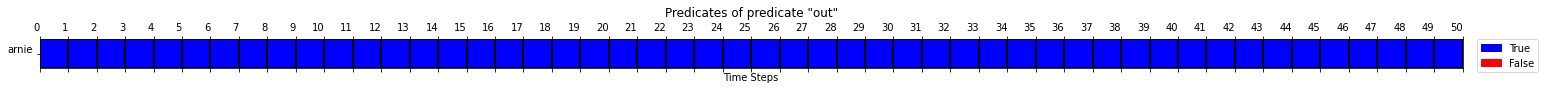

In [8]:
MAX_T = 50
scenario = "scenarios.txt"
predicates = "predicates.txt"
sorts = "sorts.txt"
StateMachine = StateMachine(predicates, sorts, scenario, MAX_T, rules)
StateMachine.run()
run_visualization(StateMachine, [])

step 10: realize nothing works and run debug in an attempt to fix it or just check if the model does what it is supposed to.  
Can you imagine there are some who still have not looked at the documentation at this point?

In [ ]:
# Run debug_mode
#StateMachine.run(debug_mode=True)